<a href="https://colab.research.google.com/github/ankit-rathi/Quantvesting_v3/blob/main/notebooks/05_MY_QUANTVESTING_JOURNEY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantvesting | My Quantvesting Journey

## Longitudinal portfolio intelligence

This notebook uses the existing EOD portfolio history to show how the portfolio has evolved over time. It does not recreate historical stock-level recommendations; it visualizes the official portfolio snapshots already persisted by Quantvesting.

> **Customer journey:** move from a point-in-time assessment to understanding progress over time.


In [3]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from google.colab import drive
drive.mount('/content/drive')
import os

PROJECT = Path("/content/drive/My Drive/quantvesting_v3")
if not PROJECT.exists():
    PROJECT = Path.cwd()

PORTFOLIO_ID = input("Enter Portfolio ID (default: ankit): ").strip() or "ankit"
HISTORY_PATH = PROJECT / "portfolio_data" / PORTFOLIO_ID / "myPortfolioDB.csv"

if not HISTORY_PATH.exists():
    raise FileNotFoundError(f"Portfolio history not found: {HISTORY_PATH}")

history = pd.read_csv(HISTORY_PATH)
history["date"] = pd.to_datetime(history["date"], errors="coerce", dayfirst=True)
history = history.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

print(f"Portfolio: {PORTFOLIO_ID}")
print(f"Snapshots: {len(history)}")
display(history.tail(10))


Mounted at /content/drive
Enter Portfolio ID (default: ankit): ankit
Portfolio: ankit
Snapshots: 373


,date,investment,cy_invested,reserve_amt,current,today_pnl_amount,today_pnl_percentage,curr_pnl_amount,curr_pnl_percentage,cy_pnl_amount,...,cy_booked_percentage,py_booked_amt,py_booked_percentage,estimate_st,est_st_pnl_amount,est_st_pnl_percentage,estimate_lt,est_lt_pnl_amount,est_lt_pnl_percentage,cagr
363,2026-07-02,13950407,18237407,245633,15325661.0,133334.0,0.88,-3014155.0,-16.53,-2782155.0,...,1.51,4287000,30.73,25485226.0,10159565.0,66.29,30765809.0,15440148.0,100.75,4.33
364,2026-07-11,13950407,18237407,245633,15267246.0,134483.0,0.89,-3072570.0,-16.85,-2840570.0,...,1.52,4287000,30.73,25482166.0,10214920.0,66.91,30755403.0,15488157.0,101.45,4.11
365,2026-07-13,13950407,18237407,245633,15351903.0,84657.0,0.55,-2987913.0,-16.38,-2755913.0,...,1.51,4287000,30.73,25482166.0,10130263.0,65.99,30755403.0,15403500.0,100.34,4.35
366,2026-07-15,13950407,18237407,245633,15269847.0,63887.0,0.42,-3069969.0,-16.83,-2837969.0,...,1.52,4287000,30.73,25479011.0,10209164.0,66.86,30752248.0,15482401.0,101.39,4.10
367,2026-07-17,13950407,18237407,245633,15247961.0,-17446.0,-0.11,-3091855.0,-16.95,-2859855.0,...,1.52,4287000,30.73,25472661.0,10224700.0,67.06,30741743.0,15493782.0,101.61,4.02
368,2026-07-26,13950407,18237407,245633,15112494.0,45299.0,0.30,-3227322.0,-17.70,-2995322.0,...,1.54,4287000,30.73,25466382.0,10353888.0,68.51,30735464.0,15622970.0,103.38,3.57
369,2026-07-29,13950407,18237407,652633,15394154.0,201864.0,1.33,-3076377.0,-16.87,-2712377.0,...,2.36,4287000,30.73,25451122.0,10056968.0,65.33,30145724.0,14751570.0,95.83,4.39
370,2026-07-31,14605407,18892407,87426,16085005.0,43476.0,0.27,-3090259.0,-16.36,-2704259.0,...,2.40,4287000,29.35,26680525.0,10595520.0,65.87,31461638.0,15376633.0,95.60,4.49
371,2026-08-05,14605407,18892407,224000,16245479.0,13968.0,0.09,-2965200.0,-15.70,-2543200.0,...,2.60,4287000,29.35,26673350.0,10427871.0,64.19,31451959.0,15206480.0,93.60,4.92
372,2026-08-07,14605407,18892407,443476,16160103.0,-44308.0,-0.27,-3093534.0,-16.37,-2628792.0,...,2.88,4287000,29.35,26665345.0,10505242.0,65.01,31439167.0,15279064.0,94.55,4.66


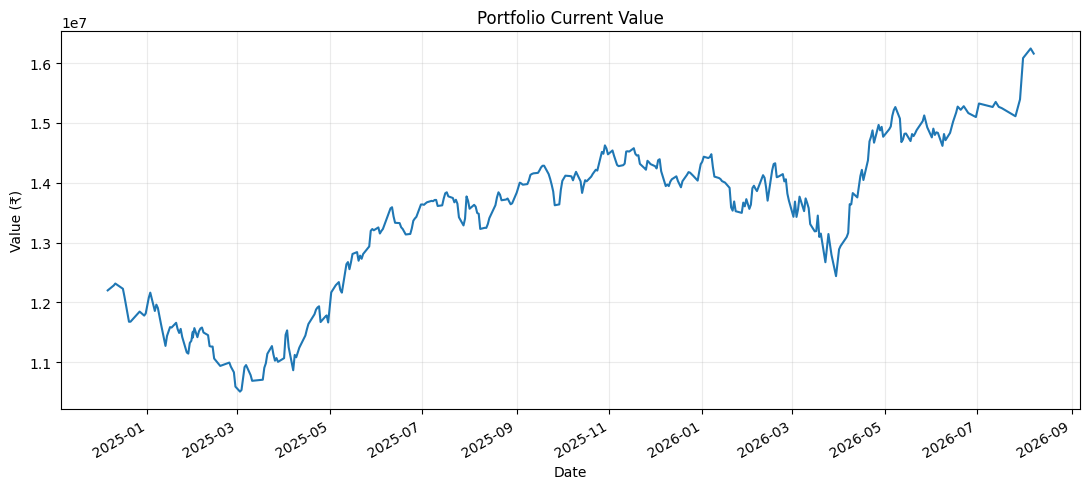

In [4]:
# Portfolio value over time
if "current" in history.columns:
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(history["date"], pd.to_numeric(history["current"], errors="coerce"))
    ax.set_title("Portfolio Current Value")
    ax.set_xlabel("Date")
    ax.set_ylabel("Value (₹)")
    ax.grid(alpha=0.25)
    fig.autofmt_xdate()
    plt.tight_layout()
    display(fig)
    plt.close(fig)


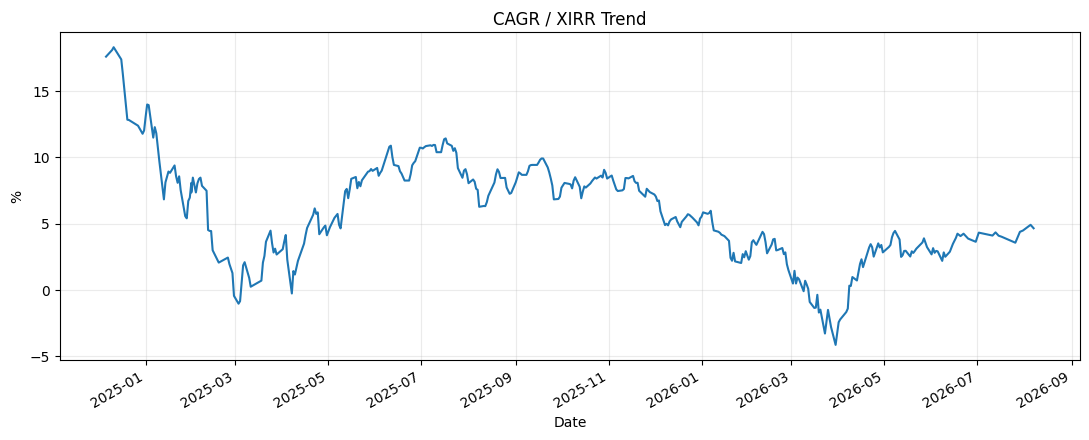

In [5]:
# XIRR / CAGR trend
metric = "cagr_xirr" if "cagr_xirr" in history.columns else ("cagr" if "cagr" in history.columns else None)
if metric:
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.plot(history["date"], pd.to_numeric(history[metric], errors="coerce"))
    ax.set_title("CAGR / XIRR Trend")
    ax.set_xlabel("Date")
    ax.set_ylabel("%")
    ax.grid(alpha=0.25)
    fig.autofmt_xdate()
    plt.tight_layout()
    display(fig)
    plt.close(fig)


## Interpretation

Use this view to understand **trajectory and progress**, not to infer historical stock-level recommendations. The underlying history is the official EOD snapshot series produced by the existing engine.

Future extensions can add NAV/benchmark comparison, health/concentration evolution and historical decision outcomes without changing the customer-facing journey.